# GRU Hyperparameters and Feature engineering tuning

Using loops to sweep tuning configs like feature sets, lookback steps, dropoutrates, etc.

Results for justifying final config selection in timeseries.py in development. Best configs will be saved

### Step 0 - Basic check that we are in virtual environment

In [1]:
import sys
print(sys.executable)

C:\Users\KJ\Documents\School\FYP\Feature Prototype ENV\.venv\Scripts\python.exe


### Step 1 - Imports

In [2]:
# * my dependencies are already installed directly in venv through terminal so it is commented out
# * tensorflow requires 3.13 or below python version, so either a downgrade from latest 3.14 or separate version needs to be installed

# %pip install yfinance pandas_ta matplotlib tensorflow scikit-learn --quiet

In [15]:
import json
from itertools import product # for nested looping
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

### Step 2 - Asset and Timeframe configurations
- tuning process is performed on all major currency pairs on both 1H and 1D timeframe
- training on 4h was initially intended, but yfinance does not pull 4h data (unlike broker's api such as Oanda)

Note:
Hourly timeframe is trained with ~7200 candles (300x24) and Daily timeframe trained with ~2520 candles (252x10). Reason there is a big gap is because hourly timeframe aims to capture contemporary intraday behaviour, while daily timeframe's 10 years of data is enough to capture observations across many multiple market regimes

In [4]:
# Major currency pairs only, values are tickers on yfinance
PAIRS = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "AUDUSD": "AUDUSD=X",
    "NZDUSD": "NZDUSD=X",
    "USDJPY": "JPY=X",
    "USDCHF": "CHF=X",
    "USDCAD": "CAD=X"
}

# Timeframes to predict, smaller ones not included as too much noise
TIMEFRAMES = {
    "1h": {"period": "300d", "interval": "1h"},
    "1d": {"period": "10y", "interval": "1d"}
}

Path("models").mkdir(exist_ok=True)

### Step 3 - Fetch trading data
- historical data retreived from yahoo finance

In [5]:
def download_data(ticker, period, interval):
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.dropna(inplace=True)
    return df

### Step 4 - Compute technical indicators
- indicators are generated using padas-ta, a TA library so as to ensure standardised implementation

In [6]:
def compute_indicators(df):
    df = df.copy()
    # RSI - standard implementation
    df["RSI"] = ta.rsi(df["Close"], length=14)
    # MACD - returns multiple columns but we only need the main line
    macd = ta.macd(df["Close"])
    df["MACD"] = macd["MACD_12_26_9"]

    # EMA20 - Indicator for medium-term trend
    df["EMA20"] = ta.ema(df["Close"], length=20)

    # Volitility indicator
    df["ATR"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)

    df.dropna(inplace=True)
    return df

### Step 5 - Hyperparameter configuration
- we will sweep through combinations and variations of these configurations like feature sets, lookback steps and dropout rate to find the 'ideal' or best performing hyper parameter
- the duration taken may be lengthy, but it is a one and done task at least
- the search space is intentionally constrained and kept to minimal as we will be running the full course of these on EACH of the currency's timeframe

In [7]:
OHLC = ["Open", "High", "Low", "Close"]
OHLC_ALL = OHLC + ["RSI", "MACD", "EMA20", "ATR"]

FEATURE_SETS = [OHLC, OHLC_ALL]
LOOKBACKS = [15, 30] # shorter term vs middle term
DROPOUTS = [0.2, 0.3]
ARCHITECTURES = [(32, 16), (64, 32)] # GRU architecture, kept to 2 to avoid exploding runtime

# Generate every possible config combination
CONFIGS = []
for features, lookback, dropout, (gru1, gru2) in product(FEATURE_SETS, LOOKBACKS, DROPOUTS, ARCHITECTURES):
    CONFIGS.append({ "features": features, "lookback": lookback, "dropout": dropout, "gru1": gru1, "gru2": gru2 })

print(f"{len(CONFIGS)} configs for each asset's timeframe")

16 configs for each asset's timeframe


### Step 6 - Sequence generation and GRU architecture
- converts time-series observation into supervised learning sequence + define GRU

In [8]:
def build_sequences(data, close_idx, lookback):
    X, y_price, y_dir = [], [], []

    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i]) # historical window used as model input
        price_change = data[i, close_idx] - data[i - 1, close_idx] # predict next candle price change
        y_price.append(price_change)
        y_dir.append(1 if price_change > 0 else 0)

    return (np.array(X), np.array(y_price), np.array(y_dir))

# Dual head GRU, one output for price movement magnitude, one for price direction prediction
def build_gru(input_shape, gru1, gru2, dropout):

    inputs = Input(shape=input_shape)

    # First recurrent layer for broad temporal patterns
    x = GRU(gru1, return_sequences=True)(inputs)
    x = Dropout(dropout)(x)

    # Second recurrent layer for compressed sequence info
    x = GRU(gru2)(x)
    x = Dropout(dropout)(x)

    x = Dense(20, activation="relu")(x) # small dense layer before output heads

    out_price = Dense(1, name="price")(x)
    out_dir = Dense(1, activation="sigmoid", name="direction")(x)

    model = Model(inputs, [out_price, out_dir])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss={ "price": "mse", "direction": "binary_crossentropy" },
        metrics={ "direction": "accuracy" }
    )

    return model

### Step 7 - Model training and Evaluation
- chronological train-split validation is used, we cant use methods like kfold cross-validation as data is series and requires order
- RobustScaler fitted on training partition only to prevent any data leakage

In [9]:
def run_config(df, cfg):
    data = df[cfg["features"]].values
    
    # 80/20 chronological split
    split_idx = int(len(data) * 0.8)
    train_raw = data[:split_idx]
    val_raw = data[split_idx:]

    # Scalar fit on training data to prevent leaks
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled = scaler.transform(val_raw)
    scaled = np.vstack([train_scaled, val_scaled])
    close_idx = cfg["features"].index("Close")

    # Build rolling sequence
    X, y_price, y_dir = build_sequences(scaled, close_idx, cfg["lookback"])

    # Maintain the chronological ordering
    split_seq = int(len(X) * 0.8)
    X_train = X[:split_seq]
    X_val = X[split_seq:]
    yp_train = y_price[:split_seq]
    yp_val = y_price[split_seq:]
    yd_train = y_dir[:split_seq]
    yd_val = y_dir[split_seq:]

    model = build_gru((cfg["lookback"], len(cfg["features"])), cfg["gru1"], cfg["gru2"], cfg["dropout"])

    # Early stoppage once validation performance peaks (help cut down train time while maintaining efficiency)
    es = EarlyStopping(patience=15, restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train,
        {"price": yp_train, "direction": yd_train},
        validation_data=(X_val, {"price": yp_val, "direction": yd_val}),
        epochs=100,
        batch_size=32,
        callbacks=[es],
        verbose=0,
    )

    preds = model.predict(X_val, verbose=0)
    dir_preds = (preds[1].flatten() > 0.5).astype(int) # sigmoid activation output, if >0.5 = 1, else 0

    acc = accuracy_score(yd_val, dir_preds)

    return acc, model, scaler, len(history.history["loss"])

### Step 8 - Hyperparameter Sweep
- to evaluate every configuration for every supported asset and it's timeframe
- afterwards, save the best model and scalar for each asset and its relevant timeframe pair
- tracks best performer config for later export

In [16]:
results = []
best_configs = {}

# Sweep through all combination
for pair_name, ticker in PAIRS.items():
    for tf_name, tf_cfg in TIMEFRAMES.items():
        print(f"\n{pair_name} | {tf_name}:")
        df = download_data(ticker, tf_cfg["period"], tf_cfg["interval"]) # fetch data from yfinance
        df = compute_indicators(df) # compute indicators (as part of feature engineering set)

        # Track the best performing config for this asset/timeframe
        best_acc = -1
        best_model = None
        best_cfg = None
        best_scaler = None

        for cfg in CONFIGS:
            acc, model, scaler, epochs_run = run_config(df, cfg) # run actual training
            results.append({
                "pair": pair_name,
                "timeframe": tf_name,
                "accuracy": acc * 100,
                "epochs": epochs_run,
                **cfg
            })
            # Keep best model
            if acc > best_acc:
                best_acc = acc
                best_model = model
                best_cfg = cfg
                best_scaler = scaler

        model_path = f"models/{pair_name}_{tf_name}.keras"
        best_model.save(model_path) # save GRU model
        joblib.dump(best_scaler, f"models/{pair_name}_{tf_name}_scaler.pkl") # save the scalar

        best_configs[f"{pair_name}_{tf_name}"] = {**best_cfg, "accuracy": round(best_acc * 100, 2), "model_path": model_path}

        print(f"Best accuracy: {best_acc * 100:.2f}%")


EURUSD | 1h:
Best accuracy: 57.82%

EURUSD | 1d:
Best accuracy: 81.09%

GBPUSD | 1h:
Best accuracy: 53.21%

GBPUSD | 1d:
Best accuracy: 84.51%

AUDUSD | 1h:
Best accuracy: 53.26%

AUDUSD | 1d:
Best accuracy: 80.98%

NZDUSD | 1h:
Best accuracy: 52.91%

NZDUSD | 1d:
Best accuracy: 80.20%

USDJPY | 1h:
Best accuracy: 55.03%

USDJPY | 1d:
Best accuracy: 53.80%

USDCHF | 1h:
Best accuracy: 53.54%

USDCHF | 1d:
Best accuracy: 83.43%

USDCAD | 1h:
Best accuracy: 55.39%

USDCAD | 1d:
Best accuracy: 80.31%


### Step 9 - Results export
- export tuning result to csv and best configs to json

In [17]:
results_df = pd.DataFrame(results)
results_df.to_csv("tuning_results.csv", index=False)

with open("best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=2)

results_df.head()

,pair,timeframe,accuracy,epochs,features,lookback,dropout,gru1,gru2
0,EURUSD,1h,57.061746,17,"[Open, High, Low, Close]",15,0.2,32,16
1,EURUSD,1h,57.061746,28,"[Open, High, Low, Close]",15,0.2,64,32
2,EURUSD,1h,57.061746,21,"[Open, High, Low, Close]",15,0.3,32,16
3,EURUSD,1h,57.061746,24,"[Open, High, Low, Close]",15,0.3,64,32
4,EURUSD,1h,57.112376,19,"[Open, High, Low, Close]",30,0.2,32,16


### Step 10 - Performance summary

In [18]:
summary = []

for key, cfg in best_configs.items():
    summary.append({
        "asset_timeframe": key,
        "accuracy": cfg["accuracy"],
        "lookback": cfg["lookback"],
        "dropout": cfg["dropout"],
        "gru1": cfg["gru1"],
        "gru2": cfg["gru2"],
    })

summary_df = pd.DataFrame(summary)
summary_df.sort_values("accuracy", ascending=False)

,asset_timeframe,accuracy,lookback,dropout,gru1,gru2
3,GBPUSD_1d,84.51,30,0.2,64,32
11,USDCHF_1d,83.43,15,0.2,32,16
1,EURUSD_1d,81.09,15,0.2,32,16
5,AUDUSD_1d,80.98,30,0.3,64,32
13,USDCAD_1d,80.31,15,0.2,32,16
7,NZDUSD_1d,80.20,30,0.2,64,32
0,EURUSD_1h,57.82,30,0.2,32,16
12,USDCAD_1h,55.39,15,0.2,64,32
8,USDJPY_1h,55.03,30,0.2,64,32
9,USDJPY_1d,53.80,15,0.3,32,16


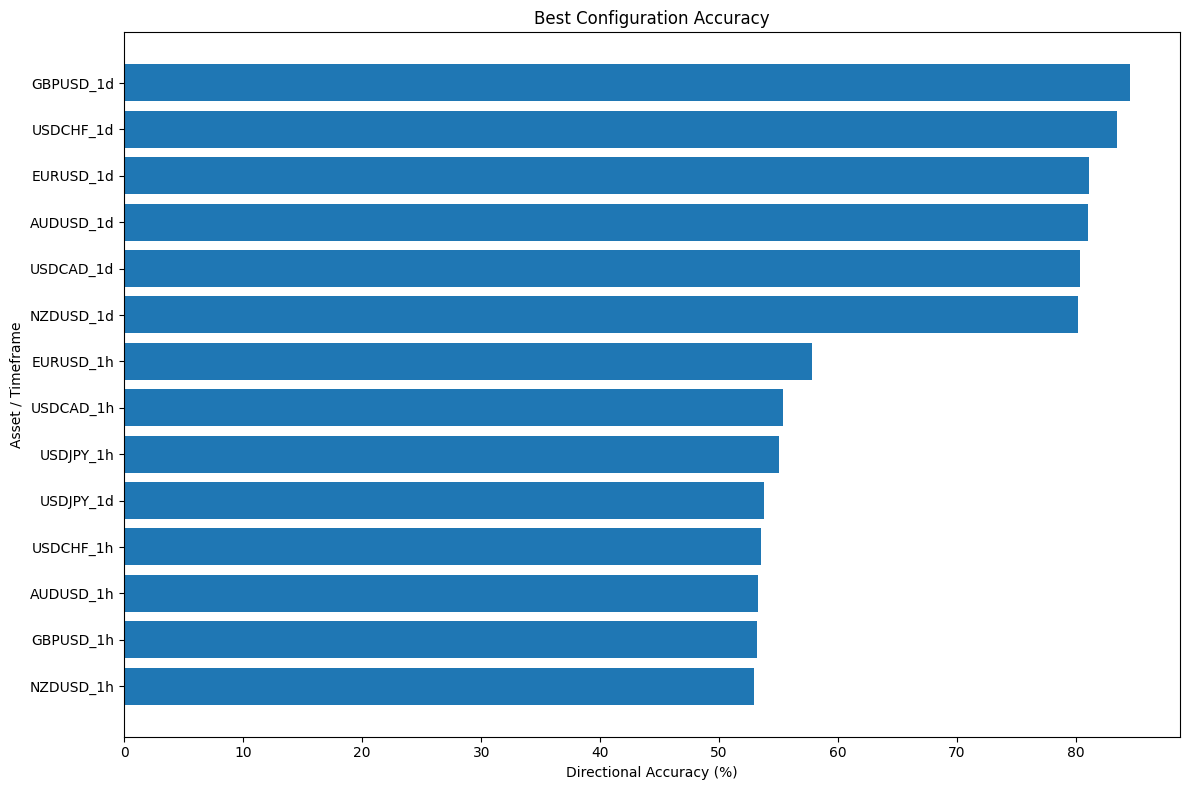

In [19]:
plt.figure(figsize=(12, 8))

plot_df = summary_df.sort_values("accuracy", ascending=True)
plt.barh(plot_df["asset_timeframe"], plot_df["accuracy"])
plt.xlabel("Directional Accuracy (%)")
plt.ylabel("Asset / Timeframe")
plt.title("Best Configuration Accuracy")
plt.tight_layout()
plt.savefig("best_config_summary.png", dpi=150)

plt.show()